Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=137571374841392 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=177,855,747 params_trainable=177,855,747


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,0.493200,0.419831,0.830000,0.827067,0.844790,0.830000,0.078187,23.456000
2,0.300700,0.365142,0.880000,0.879710,0.886468,0.880000,0.065703,19.710799
3,0.209500,0.270714,0.903333,0.902708,0.902832,0.903333,0.047513,14.254029
4,0.164200,0.269099,0.906667,0.906459,0.906641,0.906667,0.045612,13.683567


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=36.83s tok/s=0.0 ex/s=0.00 peak_mem=3.34GiB lr=7.98e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.29s tok/s=285242.9 ex/s=2228.46
[EVALUATION_PERFORMANCE] accuracy=0.8300 cost=$0.02 accuracy_per_$=39.01
[OPTIMIZER] epoch_start=1.0 global_step=150 wrapped=AcceleratedOptimizer base=AdamW lr=7.97872340425532e-06 id=137571374841392 hyperparams={'lr': 7.97872340425532e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 7.97872340425532e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[7.97872340425532e-06]
[PARAMS]   param

[EVALUATION_PERFORMANCE] tokens=81920 time=0.28s tok/s=296392.2 ex/s=2315.56
[EVALUATION_PERFORMANCE] accuracy=0.9100 cost=$0.11 accuracy_per_$=8.30

### BERT-BASE-MULTILINGUAL-CASED EVALUATION METRICS ###
{'epoch': 4.0,
 'eval_accuracy': 0.91,
 'eval_f1_macro': 0.9094029418516891,
 'eval_loss': 0.3324146568775177,
 'eval_mse': 0.05389096553197632,
 'eval_precision_macro': 0.9092060574019336,
 'eval_recall_macro': 0.91,
 'eval_runtime': 0.3415,
 'eval_samples_per_second': 878.6,
 'eval_sse': 16.167289659592896,
 'eval_steps_per_second': 14.643}


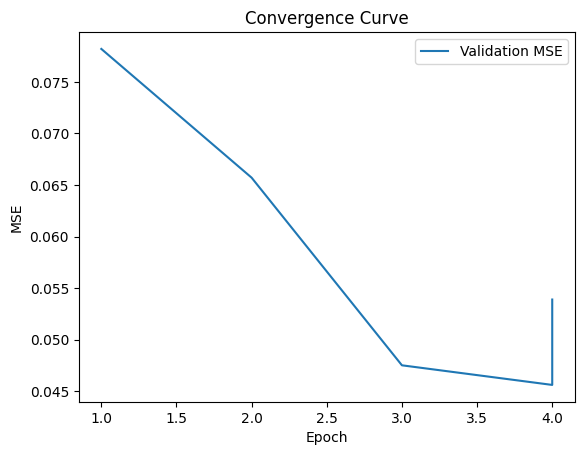

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mbert_context = context.setup_pipeline(MBert, require_translation = False)
    mbert_trainer = sentiment.train(mbert_context)

